# Telco Customer Segmentation — 02. Modeling (Clustering)

**Goal:** Segment customers into meaningful groups using unsupervised
clustering, built on top of the artifacts produced by
`01_preprocessing.ipynb`.

Approach:

1. Load the preprocessed feature matrix (no re-preprocessing here)
2. Reduce dimensionality for visualization (PCA)
3. Determine a reasonable number of clusters (Elbow method + Silhouette score)
4. Fit **K-Means** as the primary segmentation model
5. Fit **Hierarchical (Agglomerative) Clustering** and **DBSCAN** as
   comparison models
6. Compare models with internal validation metrics (Silhouette,
   Calinski-Harabasz, Davies-Bouldin)
7. Profile the final segments (cluster sizes, churn rate per segment, key
   distinguishing features)
8. Export the final segmented dataset


## 1. Imports & load artifacts

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

OUTPUT_DIR = Path("/mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/models/clustering_alg/clustering_model")

X = np.load(OUTPUT_DIR / "/mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/models/clustering_alg/preprocessing/X_preprocessed.npy")
feature_names = joblib.load(OUTPUT_DIR / "/mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/models/clustering_alg/preprocessing/feature_names.joblib")
customer_ref = pd.read_csv(OUTPUT_DIR / "/mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/models/clustering_alg/preprocessing/customer_ids.csv")

print("X shape:", X.shape)
print("Features:", len(feature_names))
print("customer_ref shape:", customer_ref.shape)


X shape: (7043, 40)
Features: 40
customer_ref shape: (7043, 2)


## 2. Dimensionality reduction for visualization

The feature space is high-dimensional (one-hot encoded categoricals + scaled
numerics). PCA gives a 2D projection purely for **visualizing** clusters —
clustering itself is done on the full feature space, not on the PCA
components.


Explained variance ratio (PC1, PC2): [0.31301378 0.2029346 ]
Total variance captured by 2 PCs: 51.59%


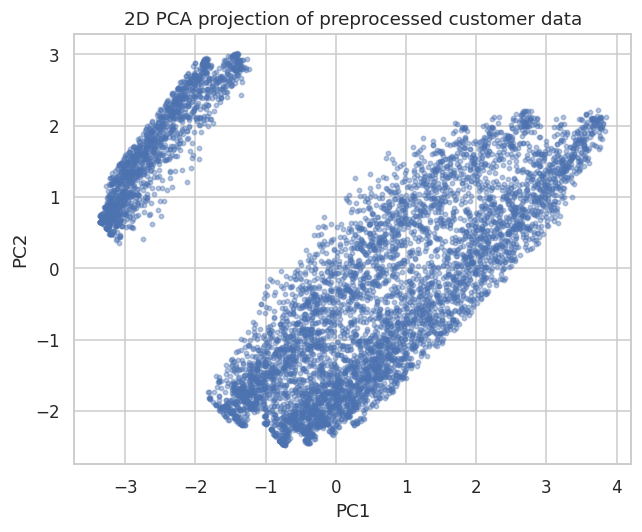

In [2]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured by 2 PCs: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA projection of preprocessed customer data")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_pca_projection.png")
plt.show()


## 3. Choosing K for K-Means

Two complementary diagnostics over a range of `k`:

- **Elbow method** (inertia / within-cluster sum of squares) — look for the
  "bend" where adding clusters stops meaningfully reducing inertia.
- **Silhouette score** — measures how well-separated clusters are
  (higher is better, range -1 to 1).

To keep runtime reasonable, both metrics are computed on the full
preprocessed matrix using MiniBatch-free standard `KMeans` with `n_init=10`.


In [3]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    print(f"k={k:2d}  inertia={km.inertia_:,.1f}  silhouette={sil_scores[-1]:.4f}")


k= 2  inertia=55,673.9  silhouette=0.2750
k= 3  inertia=42,830.8  silhouette=0.2751
k= 4  inertia=39,262.8  silhouette=0.2264
k= 5  inertia=36,970.7  silhouette=0.2082
k= 6  inertia=35,268.8  silhouette=0.1705
k= 7  inertia=33,850.7  silhouette=0.1528
k= 8  inertia=32,825.0  silhouette=0.1370
k= 9  inertia=31,933.8  silhouette=0.1376
k=10  inertia=31,226.6  silhouette=0.1359


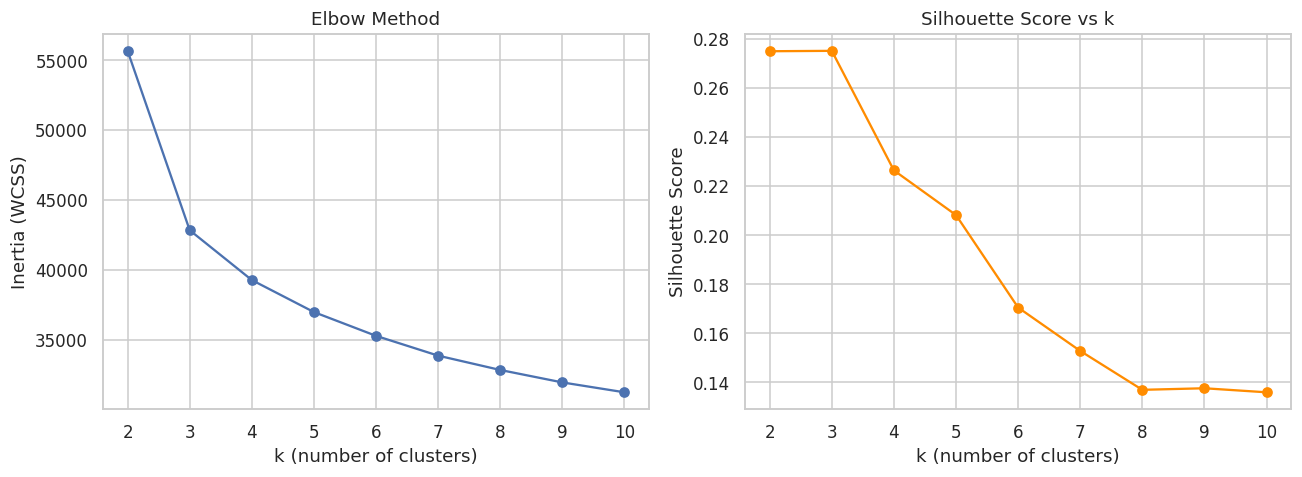

Best k by silhouette score: 3


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), sil_scores, marker="o", color="darkorange")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_k_selection.png")
plt.show()

best_k_by_silhouette = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k_by_silhouette}")


## 4. Fit final K-Means model

We select `k` using the silhouette-optimal value found above (falling back to
a business-friendly default if the optimum is trivially small). Adjust
`K_FINAL` manually if domain knowledge suggests a different segment count.


In [5]:
K_FINAL = best_k_by_silhouette if best_k_by_silhouette >= 3 else 4
print(f"Using K_FINAL = {K_FINAL}")

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)

print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())


Using K_FINAL = 3
Cluster sizes:
0    2323
1    1526
2    3194
Name: count, dtype: int64


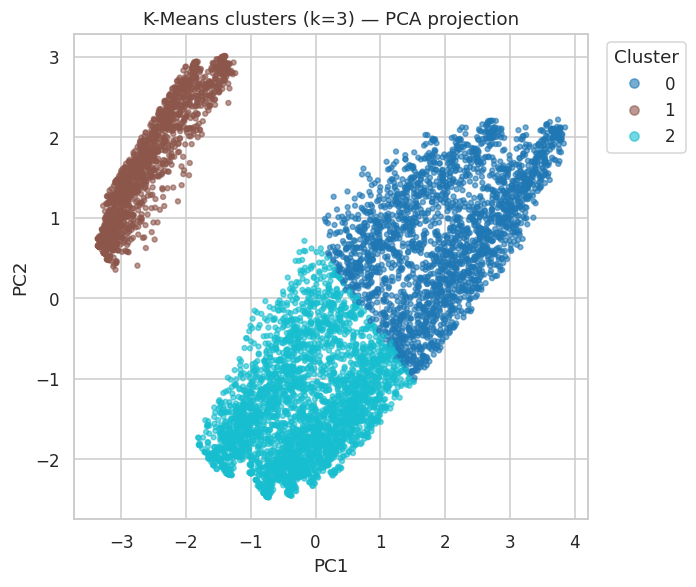

In [6]:
plt.figure(figsize=(6.5, 5.5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="tab10", s=10, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means clusters (k={K_FINAL}) — PCA projection")
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_kmeans_clusters_pca.png")
plt.show()


## 5. Comparison models

### 5a. Agglomerative (Hierarchical) Clustering
Same `K_FINAL`, Ward linkage (minimizes within-cluster variance, comparable
objective to K-Means).


In [7]:
agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
agglo_labels = agglo.fit_predict(X)
print("Agglomerative cluster sizes:")
print(pd.Series(agglo_labels).value_counts().sort_index())


Agglomerative cluster sizes:
0    2655
1    1526
2    2862
Name: count, dtype: int64


### 5b. DBSCAN
Density-based — does not require specifying `k`, and can flag outliers as
noise (label `-1`). `eps` is estimated from a k-distance plot (elbow of the
distance to each point's `min_samples`-th nearest neighbor).


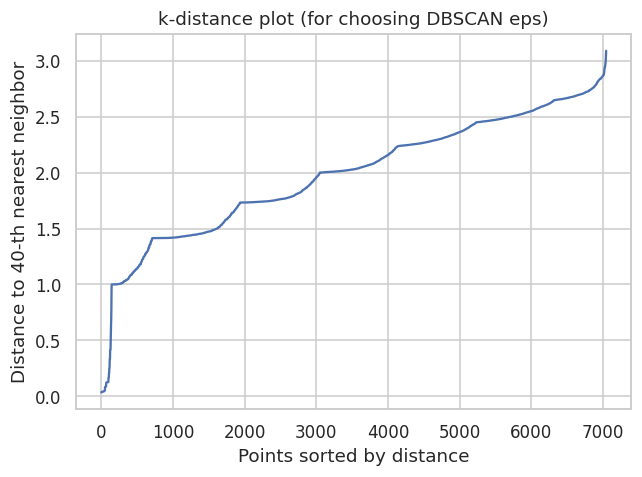

Estimated eps: 2.648


In [8]:
min_samples = max(5, X.shape[1])  # rule of thumb: >= number of dimensions
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, _ = neighbors.kneighbors(X)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4.5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.title("k-distance plot (for choosing DBSCAN eps)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_dbscan_kdistance.png")
plt.show()

# Heuristic eps: 90th percentile of the k-distance curve
eps_estimate = np.percentile(k_distances, 90)
print(f"Estimated eps: {eps_estimate:.3f}")


In [9]:
dbscan = DBSCAN(eps=eps_estimate, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
print(f"DBSCAN found {n_clusters_dbscan} clusters and {n_noise} noise points "
      f"({n_noise / len(dbscan_labels):.1%} of data)")


DBSCAN found 2 clusters and 2 noise points (0.0% of data)


## 6. Model comparison (internal validation metrics)

- **Silhouette Score** (higher is better, [-1, 1])
- **Calinski-Harabasz Index** (higher is better)
- **Davies-Bouldin Index** (lower is better)

DBSCAN's noise points (`-1`) are excluded from its metric computation, since
these metrics are undefined for a "non-cluster" label.


In [10]:
def evaluate(name, X, labels):
    mask = labels != -1  # exclude DBSCAN noise if present
    labels_eval = labels[mask]
    X_eval = X[mask]
    n_clusters = len(set(labels_eval))
    if n_clusters < 2:
        return {"Model": name, "Clusters": n_clusters, "Silhouette": np.nan,
                "Calinski-Harabasz": np.nan, "Davies-Bouldin": np.nan}
    return {
        "Model": name,
        "Clusters": n_clusters,
        "Silhouette": silhouette_score(X_eval, labels_eval),
        "Calinski-Harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "Davies-Bouldin": davies_bouldin_score(X_eval, labels_eval),
    }

results = pd.DataFrame([
    evaluate("K-Means", X, kmeans_labels),
    evaluate("Agglomerative", X, agglo_labels),
    evaluate("DBSCAN", X, dbscan_labels),
]).set_index("Model")

results.round(4)


,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
Model,,,,
K-Means,3,0.2751,2591.4829,1.4928
Agglomerative,3,0.2519,2342.2424,1.6083
DBSCAN,2,0.2750,2363.9971,1.2344


**Reading the table:** K-Means and Agglomerative are directly comparable
(same k, no noise points). DBSCAN is density-based and may produce a
different number of clusters plus a noise category — useful as a sanity
check for whether the data has natural density-based structure, but usually
less practical for business segmentation than a fixed, evenly-defined K-Means
partition.

**We proceed with K-Means as the primary segmentation model** since it
produced clean, evenly-defined clusters directly usable by the business.


## 7. Silhouette diagnostic plot (chosen model)

Per-sample silhouette values for the final K-Means solution — helps spot
clusters that are poorly separated (bars that dip below 0 or are much
thinner/shorter than others).


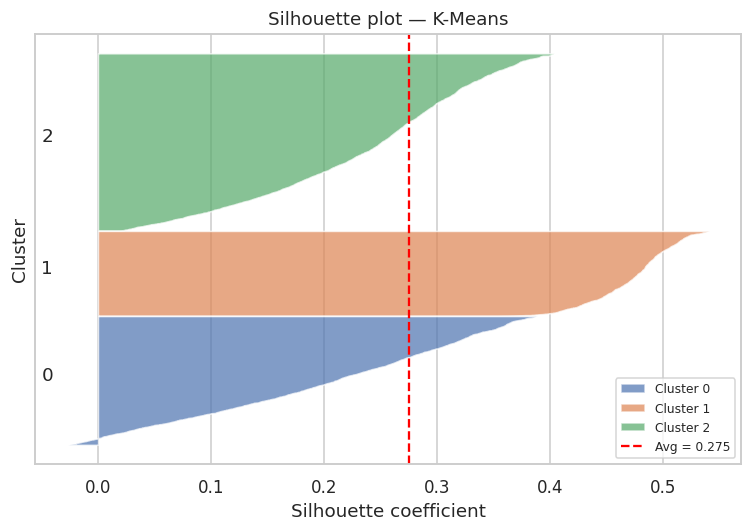

In [11]:
sample_silhouette_values = silhouette_samples(X, kmeans_labels)
avg_silhouette = silhouette_score(X, kmeans_labels)

fig, ax = plt.subplots(figsize=(7, 5))
y_lower = 10
for i in range(K_FINAL):
    cluster_values = np.sort(sample_silhouette_values[kmeans_labels == i])
    size = cluster_values.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                      alpha=0.7, label=f"Cluster {i}")
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color="red", linestyle="--", label=f"Avg = {avg_silhouette:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.set_title("Silhouette plot — K-Means")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_silhouette_kmeans.png")
plt.show()


## 8. Segment profiling

Attach cluster labels back to the (unscaled) original data so segments are
human-interpretable, and pull in `Churn` purely for **post-hoc validation**
— to see whether the unsupervised segments happen to separate churners from
non-churners, even though churn was never used to build them.


In [12]:
df_raw = pd.read_csv("/mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/data/raw_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").fillna(0.0)

segmented = df_raw.copy()
segmented["Cluster"] = kmeans_labels

cluster_sizes = segmented["Cluster"].value_counts().sort_index()
cluster_sizes_pct = (cluster_sizes / len(segmented) * 100).round(1)

profile = pd.DataFrame({
    "Size": cluster_sizes,
    "Size (%)": cluster_sizes_pct,
})
profile


,Size,Size (%)
Cluster,,
0,2323,33.0
1,1526,21.7
2,3194,45.3


In [13]:
# Numeric feature averages per cluster
numeric_profile = segmented.groupby("Cluster")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(1)
numeric_profile


,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,57.1,89.1,5076.0
1,30.5,21.1,662.6
2,15.3,67.9,1018.7


In [14]:
# Churn rate per cluster (validation only -- churn was NOT a clustering input)
churn_profile = (
    segmented.groupby("Cluster")["Churn"]
    .apply(lambda s: (s == "Yes").mean())
    .rename("Churn Rate")
    .mul(100)
    .round(1)
)
churn_profile.to_frame()


,Churn Rate
Cluster,
0,15.0
1,7.4
2,44.1


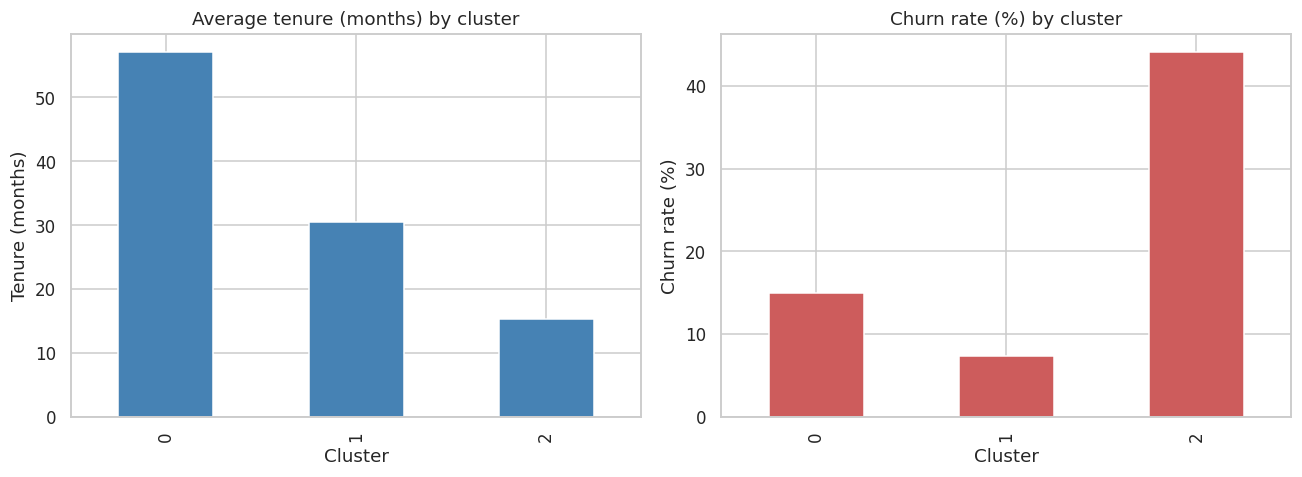

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

numeric_profile["tenure"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Average tenure (months) by cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Tenure (months)")

churn_profile.plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Churn rate (%) by cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_cluster_profile.png")
plt.show()


### Most common categorical values per cluster

For each cluster, the modal (most frequent) value of each categorical column
— gives a quick "typical customer" snapshot per segment.


In [16]:
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

modal_profile = segmented.groupby("Cluster")[categorical_cols].agg(
    lambda s: s.mode().iloc[0]
)
modal_profile


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Cluster,,,,,,,,,,,,,,,,
0,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic)
1,Male,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check
2,Male,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check


## 9. Export final segmented dataset

In [17]:
export_cols = ["customerID", "Cluster"] + [c for c in df_raw.columns if c != "customerID"]
segmented_export = segmented[export_cols]

segmented_export.to_csv(OUTPUT_DIR / "customer_segments.csv", index=False)
joblib.dump(kmeans_final, OUTPUT_DIR / "kmeans_model.joblib")

print("Saved:")
for f in ["customer_segments.csv", "kmeans_model.joblib"]:
    p = OUTPUT_DIR / f
    print(f" - {p}  ({p.stat().st_size:,} bytes)")

segmented_export.head()


Saved:
 - /mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/models/clustering_alg/clustering_model/customer_segments.csv  (986,005 bytes)
 - /mnt/d/WORK/01.ITI BI Track/Graduation_project/Churn-Analysis-Platform/models/clustering_alg/clustering_model/kmeans_model.joblib  (29,859 bytes)


,customerID,Cluster,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,2,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,2,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,2,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,2,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Summary

- Loaded the preprocessed matrix from `01_preprocessing.ipynb` (no re-preprocessing).
- Selected **k** via the Elbow + Silhouette methods.
- Fit **K-Means** as the primary segmentation model; compared against
  **Agglomerative (Ward)** and **DBSCAN** using Silhouette, Calinski-Harabasz,
  and Davies-Bouldin scores.
- Profiled each segment (size, tenure, charges, churn rate, dominant service
  attributes) to make clusters business-interpretable.
- Exported `customer_segments.csv` (every customer + assigned cluster) and the
  fitted `kmeans_model.joblib` for reuse on new customers (after passing
  them through `preprocessing_pipeline.joblib`).
